# Compositional (Multi-Observation) Inference with COMPASS

So far, in the other tutorials, we trained COMPASS on single (theta, x) pairs and asked for the
posterior given **one** observation, p(theta | x). But often you don't just have one observation:
you might have measured the same object 50 times, or you have 50 stars that all share some common
population-level parameter. You want a single, sharper posterior that uses **all** of the
observations at once, p(theta | x_1, ..., x_n).

Retraining a new network for every possible number of observations n is wasteful and often
impossible (n changes from dataset to dataset). Instead, **compositional score modeling**
(Geffner, Papamakarios & Mnih, 2023, "Compositional Score Modeling for Simulation-Based
Inference") shows that if the observations are conditionally i.i.d. given theta, the
multi-observation posterior score can be *assembled at inference time* out of n copies of the
single-observation score your network already knows, using the factorization

$$p(\theta \mid x_1, \dots, x_n) \;\propto\; p(\theta)^{1-n} \prod_{j=1}^n p(\theta \mid x_j).$$

No retraining needed &mdash; you train once on single observations, and compose as many of them
as you like at sampling time.

The tricky part is that this factorization only holds exactly for the *un-noised* posterior;
naively plugging it into a diffusion sampler (composing the noised/diffused scores the same way)
is biased, especially for larger n. COMPASS's default (`correction="gauss"`) uses the
Gaussian-precision correction of Gloeckler et al. (2024), which additionally needs a Gaussian
prior over the shared parameters (passed in explicitly, see below) and corrects the composition
so that it stays accurate even when reverse-diffusing through the composed score. Two other,
simpler composition rules are also available (see part 3).

**In this notebook we will:**
1. Build a toy problem with a *known, closed-form* posterior, so we can check the composed
   posterior against the truth.
2. Train a small COMPASS network on single (theta, x) pairs only.
3. Look at the `multi_obs_inference=True` API: `hierarchy`, `prior`, `correction`.
4. Compose posteriors for a growing number of observations N and watch them contract like
   1/sqrt(N), tracking the analytic answer.
5. Extend to a **hierarchical** case, where only *some* parameters are shared across observations.


In [1]:
import time

import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

from compass import ScoreBasedInferenceModel as SBIm

torch.manual_seed(0)
np.random.seed(0)

device = "cuda:0" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")


Using device: cpu


## 1) A Toy Problem With a Known Answer

We use the simplest possible model that still has a nontrivial multi-observation posterior: a
Gaussian prior and a Gaussian likelihood.

$$\theta \sim \mathcal{N}(\mu_0, \sigma_0^2), \qquad x \mid \theta \sim \mathcal{N}(\theta, \sigma_x^2)$$

Given a *single* observation $x$, the posterior $p(\theta \mid x)$ is Gaussian and has a
well-known closed form (this is the quantity our network will learn). Given $n$ i.i.d.
observations $x_1, \dots, x_n$, conjugacy gives us the multi-observation posterior in closed form
too:

$$p(\theta \mid x_{1:n}) = \mathcal{N}(\theta \mid \mu_n, \sigma_n^2), \qquad
\frac{1}{\sigma_n^2} = \frac{1}{\sigma_0^2} + \frac{n}{\sigma_x^2}, \qquad
\mu_n = \sigma_n^2 \left( \frac{\mu_0}{\sigma_0^2} + \frac{\sum_j x_j}{\sigma_x^2} \right).$$

Two things to notice, since we will check both of them against COMPASS later:
- The posterior mean $\mu_n$ is a precision-weighted average of the prior and the data.
- The posterior width $\sigma_n$ shrinks roughly like $1/\sqrt{n}$ for large $n$.

We will train COMPASS **only** on single (theta, x) pairs (n=1) &mdash; it never sees more than
one observation during training &mdash; and then use compositional inference to combine as many
observations as we like at sampling time.


In [2]:
# Toy model hyperparameters
MU0, S0 = 0.0, 1.0   # prior: theta ~ N(MU0, S0^2)
SX = 1.0             # likelihood: x | theta ~ N(theta, SX^2)


def simulate(n):
    """Draw n i.i.d. (theta, x) pairs from the generative model."""
    theta = MU0 + S0 * torch.randn(n, 1)
    x = theta + SX * torch.randn(n, 1)
    return theta, x


def analytic_multiobs_posterior(x_obs):
    """Closed-form N(mu_n, sigma_n^2) given a stack of n observations x_obs, shape (n, 1)."""
    n = x_obs.shape[0]
    precision_n = 1.0 / S0**2 + n / SX**2
    sigma_n = (1.0 / precision_n) ** 0.5
    mu_n = (1.0 / precision_n) * (MU0 / S0**2 + x_obs.sum() / SX**2)
    return mu_n.item(), sigma_n


# Training data: single (theta, x) pairs only
theta_train, x_train = simulate(50_000)
theta_val, x_val = simulate(3_000)
print("Training pairs:", theta_train.shape, x_train.shape)


Training pairs: torch.Size([50000, 1]) torch.Size([50000, 1])


## 2) Train a Small COMPASS Network

The network only ever sees single observations during training (`theta`, `x` are both shape
`(n_samples, 1)`, one row per simulation &mdash; there is no notion of "multiple observations of
the same theta" here). Because the problem is 1-D and simple, a tiny transformer trained for a
couple of minutes on CPU is enough.

Two choices worth calling out:
- `time_sampling="mixture"` (the default) mixes uniform-time and log-sigma-time sampling during
  training so the network also learns accurate scores at small noise levels &mdash; this matters
  a lot for compositional inference, since composing many observations sharpens the posterior
  well below what a single observation would resolve, and the reverse diffusion has to end there.
- `sigma` (the VESDE noise scale) just needs to comfortably cover the range of theta/x &mdash;
  here a handful of prior standard deviations is enough.


In [3]:
sbim = SBIm(
    nodes_size=2,       # 1 theta + 1 x
    sde_type="vesde",
    sigma=8.0,
    hidden_size=32,
    depth=2,
    num_heads=4,
    mlp_ratio=2,
    device=device,
)

t0 = time.time()
sbim.train(
    theta=theta_train,
    x=x_train,
    theta_val=theta_val,
    x_val=x_val,
    batch_size=256,
    max_epochs=80,
    early_stopping_patience=15,
    time_sampling="mixture",
    device=device,
    verbose=False,
    path="data/compositional_inference",
)
print(f"Training took {(time.time() - t0)/60:.1f} minutes")


Training took 2.9 minutes


Let's sanity-check the network on a single observation before moving to compositional
inference: does `model.sample(x=..., ...)` recover the known single-observation posterior?


In [4]:
x_obs_single = torch.tensor([[1.5]])
samples_single = sbim.sample(x=x_obs_single, num_samples=4000, timesteps=100, device=device, verbose=False)

mu_true, sigma_true = analytic_multiobs_posterior(x_obs_single)
print(f"Analytic:  mean={mu_true:.3f}, std={sigma_true:.3f}")
print(f"COMPASS:   mean={samples_single[0,:,0].mean():.3f}, std={samples_single[0,:,0].std():.3f}")


Analytic:  mean=0.750, std=0.707
COMPASS:   mean=0.651, std=0.732


## 3) The Compositional Inference API

Compositional (multi-observation) inference is a special mode of the usual `model.sample(...)`
call. Instead of `x` being a single observation, it is a **stack** of `n` i.i.d. observations
(shape `(n, num_observed_features)`), and you set `multi_obs_inference=True`:

```python
samples = model.sample(
    x=x_obs_stack,                       # (n_obs, num_observed_features)
    multi_obs_inference=True,
    hierarchy=[0],                       # which theta-columns are SHARED across observations
    prior=([MU0], [S0]),                 # Gaussian prior (mean, std) over the hierarchy dims
    correction="gauss",                  # "gauss" (default), "uncorrected", or "fnpe"
    num_samples=2000,
    timesteps=100,
)
```

The important new arguments:

- **`hierarchy`** &mdash; the indices of the theta columns that are *shared* (global) across the
  n observations, i.e. the ones we actually want to pool information about. Any theta columns
  *not* listed are treated as local, per-observation latents (see part 5 for a worked example).
  Defaults to *all* latent columns, i.e. a fully shared theta.
- **`prior`** &mdash; the Gaussian prior `(mean, std)` over the hierarchy dimensions. This is
  **required in practice**: the default `correction="gauss"` needs it to correctly weigh the
  prior term in the composition, and other composition rules use it to build the "diffused
  prior" score. If you omit it, COMPASS falls back to a standard normal N(0, 1) prior with a loud
  warning &mdash; only correct if your training parameters happen to be standardized to zero
  mean/unit variance.
- **`correction`** &mdash; the composition rule:
    - `"gauss"` (default, recommended): the Gaussian-precision correction of Gloeckler et al.
      (2024). Valid inside the normal reverse-diffusion samplers (`method="dpm"` or `"euler"`).
      Needs an estimate of each single-observation posterior's precision on the hierarchy
      dimensions &mdash; by default COMPASS estimates this automatically with one extra
      single-observation sampling pass (`posterior_precision=None`), but you can also pass it in
      yourself if you already know it.
    - `"uncorrected"`: the raw, un-corrected composition. Cheap, exact as the noise level goes to
      zero, but biased at higher noise levels &mdash; mostly useful as a quick baseline.
    - `"fnpe"`: the original Geffner et al. (2023) bridging-density score (their Eq. 7). This is
      **only** valid together with `method="langevin"` (annealed Langevin dynamics); plugging it
      into the `"dpm"`/`"euler"` reverse-diffusion samplers diverges.

The result comes back with the same "one row per observation" layout as the input, shape
`(n_obs, num_samples, num_latent_features)`. On the **shared** (hierarchy) columns, every
observation-row contains the *same* composed posterior samples (they are kept synchronized during
sampling), so `samples[0]` already gives you everything; on **local** columns the rows differ
&mdash; row `i` holds the posterior for observation `i`'s own local parameter (see part 5).


## 4) Composing More and More Observations

Now the fun part: we simulate a single "true" theta, generate a growing number of observations
of it, and see the composed posterior sharpen &mdash; while staying centered on the analytic
answer.


In [5]:
torch.manual_seed(123)
theta_true = MU0 + S0 * torch.randn(1)
N_list = [1, 5, 20, 50]
N_max = max(N_list)

# One shared pool of observations; the first N of them are used for each panel below
x_pool = theta_true + SX * torch.randn(N_max, 1)

results = {}
for n in N_list:
    x_obs = x_pool[:n]
    t0 = time.time()
    samples = sbim.sample(
        x=x_obs,
        multi_obs_inference=True,
        hierarchy=[0],
        prior=([MU0], [S0]),
        correction="gauss",
        num_samples=4000,
        timesteps=100,
        device=device,
        verbose=False,
    )
    dt = time.time() - t0
    mu_true_n, sigma_true_n = analytic_multiobs_posterior(x_obs)
    theta_samples = samples[0, :, 0]
    results[n] = dict(
        samples=theta_samples,
        mu_true=mu_true_n,
        sigma_true=sigma_true_n,
        mu_compass=theta_samples.mean().item(),
        sigma_compass=theta_samples.std().item(),
        time=dt,
    )
    print(f"N={n:>3d}  analytic=({mu_true_n:6.3f}, {sigma_true_n:.3f})   "
          f"compass=({results[n]['mu_compass']:6.3f}, {results[n]['sigma_compass']:.3f})   "
          f"[{dt:.1f}s]")

print(f"\ntrue theta = {theta_true.item():.3f}")


N=  1  analytic=( 0.119, 0.707)   compass=( 0.117, 0.746)   [5.5s]


N=  5  analytic=( 0.054, 0.408)   compass=( 0.020, 0.414)   [14.0s]


N= 20  analytic=( 0.145, 0.218)   compass=( 0.108, 0.241)   [48.4s]


N= 50  analytic=(-0.222, 0.140)   compass=(-0.351, 0.166)   [174.1s]

true theta = -0.111


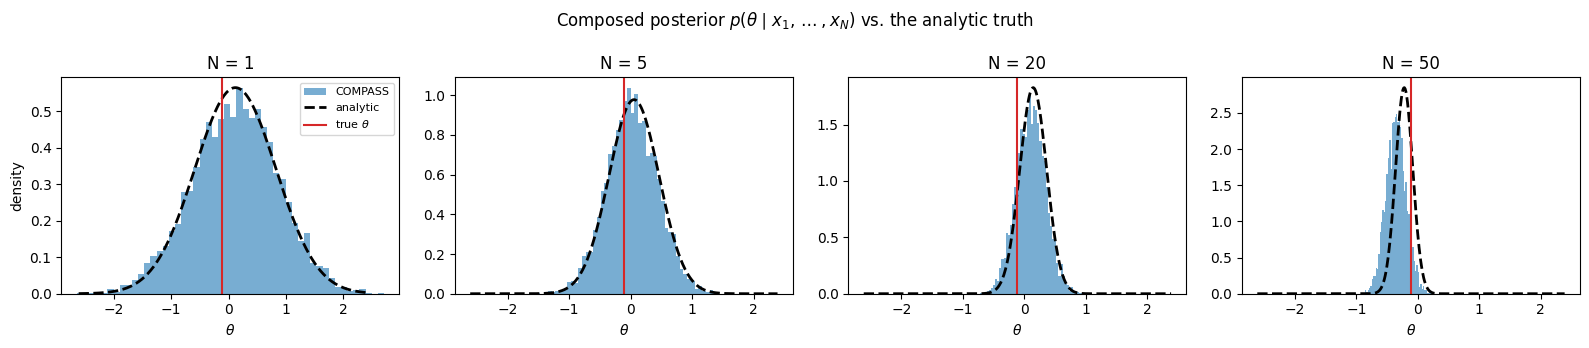

In [6]:
fig, axes = plt.subplots(1, len(N_list), figsize=(16, 3.5), sharey=False)

theta_grid = np.linspace(theta_true.item() - 2.5, theta_true.item() + 2.5, 400)

for ax, n in zip(axes, N_list):
    r = results[n]
    ax.hist(r["samples"].to("cpu").numpy(), bins=50, density=True, alpha=0.6,
            color="tab:blue", label="COMPASS")
    ax.plot(theta_grid, norm.pdf(theta_grid, r["mu_true"], r["sigma_true"]),
            color="black", lw=2, ls="--", label="analytic")
    ax.axvline(theta_true.item(), color="tab:red", lw=1.5, label=r"true $\theta$")
    ax.set_title(f"N = {n}")
    ax.set_xlabel(r"$\theta$")

axes[0].set_ylabel("density")
axes[0].legend(fontsize=8)
fig.suptitle(r"Composed posterior $p(\theta \mid x_1, \dots, x_N)$ vs. the analytic truth")
plt.tight_layout()
plt.show()


And the headline result of compositional inference: the posterior width should shrink like
$1/\sqrt{N}$, and COMPASS should track the analytic curve throughout.


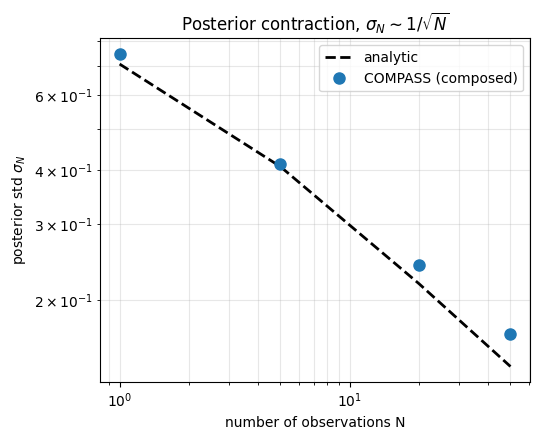

In [7]:
N_arr = np.array(N_list)
sigma_compass = np.array([results[n]["sigma_compass"] for n in N_list])
sigma_true = np.array([results[n]["sigma_true"] for n in N_list])

fig, ax = plt.subplots(figsize=(5.5, 4.5))
ax.loglog(N_arr, sigma_true, "k--", lw=2, label="analytic")
ax.loglog(N_arr, sigma_compass, "o", color="tab:blue", ms=8, label="COMPASS (composed)")
ax.set_xlabel("number of observations N")
ax.set_ylabel(r"posterior std $\sigma_N$")
ax.set_title(r"Posterior contraction, $\sigma_N \sim 1/\sqrt{N}$")
ax.legend()
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()


## 5) A Hierarchical Variant: Shared *and* Local Parameters

Real problems are often *hierarchical*: some parameters are genuinely shared across observations
(a population-level mean, say), while others are specific to each observation (a per-star
nuisance offset, per-measurement noise realization, etc.) and should **not** be pooled.

We extend the toy model to two parameters, $\theta = (\theta_g, \theta_l)$:

$$\theta_g \sim \mathcal{N}(\mu_g, \sigma_g^2) \quad \text{(shared across all observations)}$$
$$\theta_{l,i} \sim \mathcal{N}(0, \sigma_l^2) \quad \text{(local to observation } i\text{)}$$
$$x_i \mid \theta_g, \theta_{l,i} \sim \mathcal{N}(\theta_g + \theta_{l,i}, \sigma_x^2)$$

Only $\theta_g$ should be composed across observations; each $\theta_{l,i}$ has its own posterior
given only $x_i$ (and the composed $\theta_g$). We tell COMPASS this with `hierarchy=[0]`
(column 0 = $\theta_g$; column 1 = $\theta_l$ is left out, so it stays local/per-observation).


In [8]:
MUG, S0G = 0.0, 1.0   # prior over the shared theta_g
S0L = 1.0             # spread of the local theta_l
SXH = 0.5             # observation noise


def simulate_hier(n):
    theta_g = MUG + S0G * torch.randn(n, 1)
    theta_l = S0L * torch.randn(n, 1)
    x = theta_g + theta_l + SXH * torch.randn(n, 1)
    theta = torch.cat([theta_g, theta_l], dim=1)
    return theta, x


theta_h_train, x_h_train = simulate_hier(60_000)
theta_h_val, x_h_val = simulate_hier(3_000)

sbim_hier = SBIm(
    nodes_size=3,   # theta_g, theta_l, x
    sde_type="vesde",
    sigma=8.0,
    hidden_size=32,
    depth=3,
    num_heads=4,
    mlp_ratio=2,
    device=device,
)

t0 = time.time()
sbim_hier.train(
    theta=theta_h_train,
    x=x_h_train,
    theta_val=theta_h_val,
    x_val=x_h_val,
    batch_size=256,
    max_epochs=80,
    early_stopping_patience=15,
    time_sampling="mixture",
    device=device,
    verbose=False,
    path="data/compositional_inference_hier",
)
print(f"Training took {(time.time() - t0)/60:.1f} minutes")


Training took 2.3 minutes


Now we simulate one shared $\theta_g$, `n` different local $\theta_{l,i}$, and their
observations, and run compositional inference with `hierarchy=[0]`. Hierarchical models benefit
from denser Langevin correction (`corrector_steps_interval=1, corrector_steps=10, snr=0.2`) since
the diagonal Gaussian correction can't fully capture the coupling between the shared and local
parameters &mdash; see the practical tips below.


In [9]:
torch.manual_seed(321)
n_hier = 30
theta_g_true = MUG + S0G * torch.randn(1)
theta_l_true = S0L * torch.randn(n_hier, 1)
x_hier = theta_g_true + theta_l_true + SXH * torch.randn(n_hier, 1)

samples_hier = sbim_hier.sample(
    x=x_hier,
    multi_obs_inference=True,
    hierarchy=[0],
    prior=([MUG], [S0G]),
    correction="gauss",
    corrector_steps_interval=1,
    corrector_steps=10,
    snr=0.2,
    num_samples=3000,
    timesteps=100,
    device=device,
    verbose=False,
)
print("samples shape (n_obs, num_samples, num_latent):", samples_hier.shape)

# Analytic posterior for theta_g, marginalizing the (unknown) local theta_l of each observation:
# x_i | theta_g ~ N(theta_g, S0L^2 + SXH^2)
var_eff = S0L**2 + SXH**2
precision_g = 1.0 / S0G**2 + n_hier / var_eff
sigma_g_true = (1.0 / precision_g) ** 0.5
mu_g_true = (MUG / S0G**2 + x_hier.sum() / var_eff) / precision_g

theta_g_samples = samples_hier[0, :, 0]  # shared column: identical across observation-rows
print(f"theta_g   analytic=({mu_g_true:.3f}, {sigma_g_true:.3f})   "
      f"compass=({theta_g_samples.mean():.3f}, {theta_g_samples.std():.3f})   "
      f"true={theta_g_true.item():.3f}")


samples shape (n_obs, num_samples, num_latent): torch.Size([30, 3000, 2])
theta_g   analytic=(-0.827, 0.200)   compass=(-1.040, 0.325)   true=-1.135


And the local column: each observation-row now holds a **different** posterior, one per
$\theta_{l,i}$. Let's check a handful of them against their own analytic answer
$\theta_{l,i} \mid \hat\theta_g, x_i$.


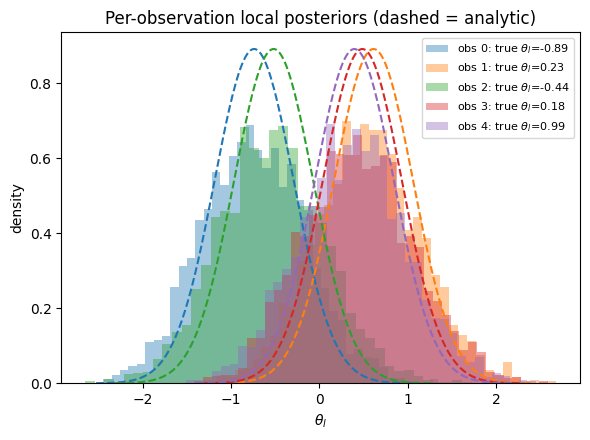

In [10]:
theta_l_samples = samples_hier[:, :, 1]  # (n_obs, num_samples) -- one posterior per observation

mu_g_hat = theta_g_samples.mean().item()
fig, ax = plt.subplots(figsize=(6, 4.5))
for i in range(5):
    # analytic local posterior given the (estimated) shared theta_g and this observation's x_i
    prec_l = 1.0 / S0L**2 + 1.0 / SXH**2
    m_l = (x_hier[i].item() - mu_g_hat) / SXH**2 / prec_l
    s_l = (1.0 / prec_l) ** 0.5
    grid = np.linspace(m_l - 4 * s_l, m_l + 4 * s_l, 200)
    ax.plot(grid, norm.pdf(grid, m_l, s_l), color=f"C{i}", ls="--")
    ax.hist(theta_l_samples[i].to("cpu").numpy(), bins=40, density=True, alpha=0.4, color=f"C{i}",
            label=fr"obs {i}: true $\theta_l$={theta_l_true[i,0]:.2f}")

ax.set_xlabel(r"$\theta_l$")
ax.set_ylabel("density")
ax.set_title("Per-observation local posteriors (dashed = analytic)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


So `multi_obs_inference=True` gives you both pieces at once: a single, sharpened posterior
for the shared parameters, *and* the individual per-observation posteriors for the local ones
&mdash; correctly conditioned on the (composed) shared parameter.


## 6) Practical Tips

- **Always pass `prior=(mean, std)`.** It is required for the default `correction="gauss"` to
  correctly weigh the prior term, and is used by every correction mode to build the "diffused
  prior" score. Omitting it silently falls back to a standard normal N(0, 1) prior (with a
  warning) &mdash; only correct if your training parameters were standardized that way.
- **Train with `time_sampling="mixture"`** (the default). Compositional inference sharpens the
  posterior well beyond what a single observation resolves, especially as N grows, so the reverse
  diffusion needs to end at a much smaller noise scale than usual. A network trained only with
  uniform-time sampling undersamples exactly that regime and its scores become inaccurate right
  where the composed posterior lives.
- **`hierarchy` picks out the shared columns.** Everything else in theta is treated as a local,
  per-observation latent and keeps its own individual score &mdash; no composition, no prior
  needed for those dimensions.
- **Hierarchical models (shared + local latents) want denser Langevin correction:**
  `corrector_steps_interval=1, corrector_steps=10, snr=0.2` noticeably improves the composed
  posterior, because the default Gaussian correction is diagonal and can't fully capture the
  coupling between shared and local parameters at intermediate noise levels.
- **`correction="fnpe"` needs `method="langevin"`.** It implements the original Geffner et al.
  (2023) bridging-density score, which is only a valid sampling target for annealed Langevin
  dynamics &mdash; plugging it into the default `"dpm"`/`"euler"` reverse-diffusion samplers
  diverges (COMPASS prints a warning if you try).
- **Large N is limited by the network's own accuracy, not by the composition itself.** The
  composed posterior contracts like $1/\sqrt{N}$, so any systematic bias in the trained score
  (constant in absolute theta-units) becomes more visible relative to the shrinking posterior
  width as N grows. If you see this in practice, train longer / on more simulations &mdash; the
  composition machinery itself is exact (verified against analytic scores up to N=200 in
  `tests/test_multiobs_analytic.py`).
- **`posterior_precision` can be supplied directly** (for `correction="gauss"`) if you already
  know the single-observation posterior precision on the hierarchy dimensions &mdash; this skips
  COMPASS's automatic estimation pass and saves some compute.
